# 05 — Quinto estudio: comparación BB vs CBB

Este notebook compara BB tipo Lahiri y CBB toroidal pareado para un escenario base.

In [ ]:
# Ejecutar una vez si aparece ModuleNotFoundError
from pathlib import Path
import sys, subprocess
cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd.parent.parent]
ROOT = None
for path in candidates:
    if (path / "pyproject.toml").exists() and (path / "src" / "codispersion_bootstrap").exists():
        ROOT = path
        break
if ROOT is None:
    raise RuntimeError(f"No encontré la carpeta raíz del proyecto. Estoy parado en: {cwd}")
print("Carpeta raíz encontrada:", ROOT)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", str(ROOT)])
print("Paquete instalado correctamente. Reinicia el kernel después de esta celda si es primera vez.")

In [1]:
from codispersion_bootstrap import Scenario, run_mc_study_lmc, results_to_dataframe
from codispersion_bootstrap.plotting import plot_variance_ratio, plot_coverage

## Test

In [2]:
H = [(1,0), (0,1), (1,1), (-1,1), (2,0), (0,2), (2,2), (-2,2)]
sc_test = Scenario(
    rho0=0.5,
    range_pix=3.5,
    anis_mode="aniso",
    anis_ratio=2.0,
    angle_deg=45.0,
    nu=1.0,
    n1=64,
    n2=64,
    B_boot=50,
    b_block=12,
    R_mc=10,
)
res_test = run_mc_study_lmc(sc_test, H, seed=2025)
df_test = results_to_dataframe(res_test, extra={"b": sc_test.b_block, "rho0": sc_test.rho0, "range_pix": sc_test.range_pix, "anis_mode": sc_test.anis_mode})
df_test

,h,h1,h2,rho_hat_mean,Var_MC,Var*_BB_mean,ratio_BB,coverage_BB,Var*_CBB_mean,ratio_CBB,coverage_CBB,b,rho0,range_pix,anis_mode
0,"(1, 0)",1,0,0.483804,0.002560,0.001073,0.419083,0.5,0.001312,0.512619,0.5,12,0.5,3.5,aniso
1,"(0, 1)",0,1,0.482171,0.001704,0.001104,0.647983,0.7,0.001191,0.698843,0.7,12,0.5,3.5,aniso
2,"(1, 1)",1,1,0.485342,0.003225,0.001097,0.340029,0.6,0.001355,0.420282,0.7,12,0.5,3.5,aniso
3,"(-1, 1)",-1,1,0.479863,0.000817,0.002103,2.574674,0.8,0.002080,2.545997,0.8,12,0.5,3.5,aniso
4,"(2, 0)",2,0,0.485742,0.003665,0.001331,0.363034,0.6,0.001622,0.442510,0.7,12,0.5,3.5,aniso
5,"(0, 2)",0,2,0.485797,0.002765,0.001338,0.483783,0.7,0.001478,0.534763,0.8,12,0.5,3.5,aniso
6,"(2, 2)",2,2,0.489654,0.007321,0.001905,0.260199,0.6,0.002338,0.319331,0.8,12,0.5,3.5,aniso
7,"(-2, 2)",-2,2,0.478869,0.001037,0.001909,1.841554,0.8,0.001938,1.869786,0.9,12,0.5,3.5,aniso


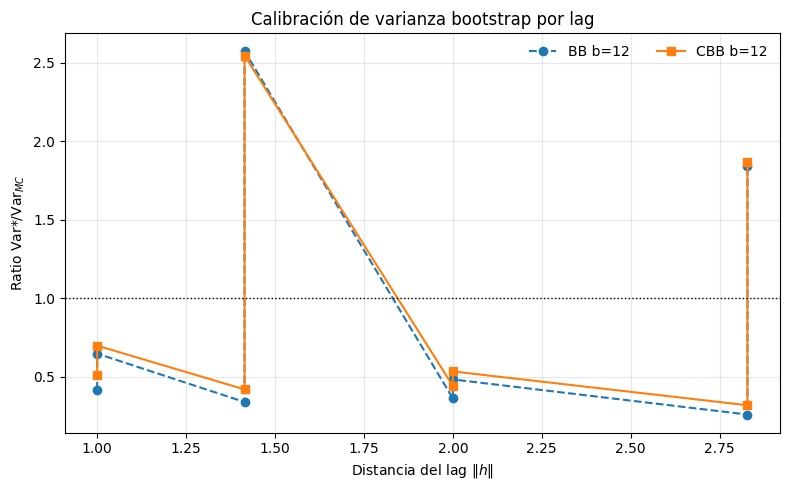

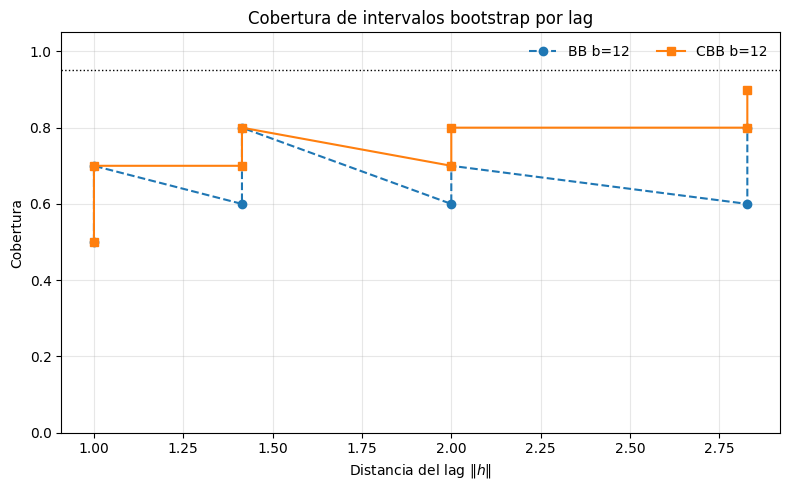

In [3]:
plot_variance_ratio(df_test)
plot_coverage(df_test);

## Simulación

In [ ]:
import pandas as pd
H = [(1,0), (0,1), (1,1), (-1,1), (2,0), (0,2), (2,2), (-2,2)]

b_list = [16, 32, 48]

all_results = {}
dfs = []

for idx, b in enumerate(b_list):
    sc = Scenario(
        rho0=0.5,
        range_pix=3.5,
        anis_mode="aniso",
        anis_ratio=2.0,
        angle_deg=45.0,
        nu=1.0,
        n1=256,
        n2=256,
        B_boot=800,
        b_block=b,      # aquí va un solo número
        R_mc=100,
    )

    res = run_mc_study_lmc(sc, H, seed=2025 + idx)
    all_results[b] = res

    df_b = results_to_dataframe(
        res,
        extra={
            "b": b,
            "rho0": sc.rho0,
            "range_pix": sc.range_pix,
            "anis_mode": sc.anis_mode,
            "anis_ratio": sc.anis_ratio,
            "angle_deg": sc.angle_deg,
            "nu": sc.nu,
            "n1": sc.n1,
            "n2": sc.n2,
            "B_boot": sc.B_boot,
            "R_mc": sc.R_mc,
        }
    )

    dfs.append(df_b)

df = pd.concat(dfs, ignore_index=True)
df

In [ ]:
plot_variance_ratio(df)
plot_coverage(df);

In [ ]:
import numpy as np

best_b = None
best_score = np.inf

for b, res in all_results.items():
    ratios_cbb = [
        res[h]["ratio_CBB"]
        for h in H
        if np.isfinite(res[h]["ratio_CBB"])
    ]

    score = abs(np.mean(ratios_cbb) - 1.0)

    if score < best_score:
        best_score = score
        best_b = b

print("b óptimo:", best_b)
print("score:", best_score)

In [ ]:
df.to_csv("../results/quinto_estudio_bb_vs_cbb_quick.csv", index=False)